# **CCLEX's LAKBxAI FINAL OVERTURE: ESCAPE FROM PLANET SAGO SUPER MODEL**


## **Prerequisites and Setup**

In [ ]:
!pip install fuzzylogic

### Checking Library Versions

In [ ]:
!pip list

Package                            Version
---------------------------------- -------------------
absl-py                            1.4.0
accelerate                         0.34.2
aiohappyeyeballs                   2.4.3
aiohttp                            3.10.10
aiosignal                          1.3.1
alabaster                          0.7.16
albucore                           0.0.19
albumentations                     1.4.20
altair                             4.2.2
annotated-types                    0.7.0
anyio                              3.7.1
argon2-cffi                        23.1.0
argon2-cffi-bindings               21.2.0
array_record                       0.5.1
arviz                              0.20.0
astropy                            6.1.4
astropy-iers-data                  0.2024.11.4.0.33.34
astunparse                         1.6.3
async-timeout                      4.0.3
atpublic                           4.1.0
attrs                              24.2.0
audioread        

### Import Libraries

In [ ]:
# For General Use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

# For FIS
from fuzzylogic.classes import Domain
from fuzzylogic.functions import gauss, sigmoid, trapezoid

# For Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## **Fuzzy Inference System Generator Model**

#### Helper Functions

In [ ]:
def fuzzy_OR(*args):
    return np.max(args)

def fuzzy_AND(*args):
    return np.min(args)

In [ ]:
def defuzzify(fuzzy_tup):
    return np.min([0*fuzzy_tup[0] + 50*fuzzy_tup[1] + 100*fuzzy_tup[2], 100])

### **I. Weather Condition**

#### Fuzzy Sets

##### For Heat

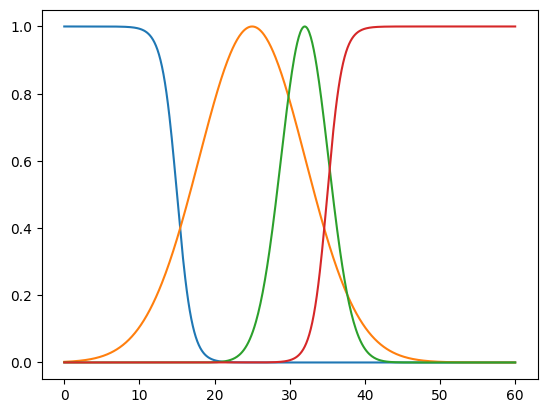

In [ ]:
# Define the domain (universe of discourse) for heat: 0°C to 60°C
heat = Domain("Heat", 0, 60, res=0.1)

# Define Gaussian membership functions for the heat levels
heat.normal = sigmoid(1, -1, 15)
heat.hazardous = gauss(c=25, b=0.01, c_m=1)
heat.caution = gauss(c=32, b=0.05, c_m=1)
heat.danger = sigmoid(1, 1, 35)

heat.normal.plot()
heat.hazardous.plot()
heat.caution.plot()
heat.danger.plot()

In [ ]:
def heat_membership(heat_value):
    normal = heat.normal(heat_value)
    hazardous = heat.hazardous(heat_value)
    caution = heat.caution(heat_value)
    danger = heat.danger(heat_value)
    return normal, hazardous, caution, danger

##### For Precipitation

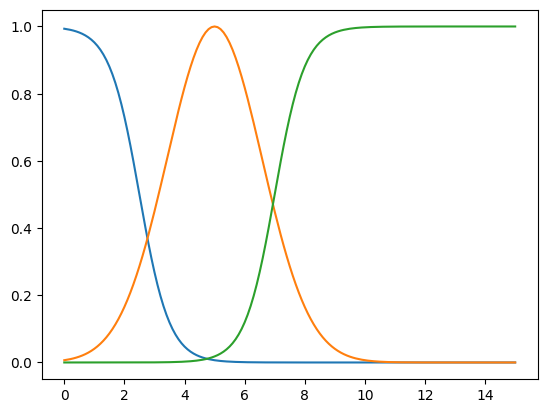

In [ ]:
# Define the universe of discourse for precipitation: 0 mm to 15 mm
precipitation = Domain("Precipitation", 0, 15, res=0.1)

precipitation.light = sigmoid(1, -2, 2.5)
precipitation.moderate = gauss(c=5, b=0.2, c_m=1)
precipitation.heavy = sigmoid(1, 2, 7)


precipitation.light.plot()
precipitation.moderate.plot()
precipitation.heavy.plot()

##### For Flood Risk

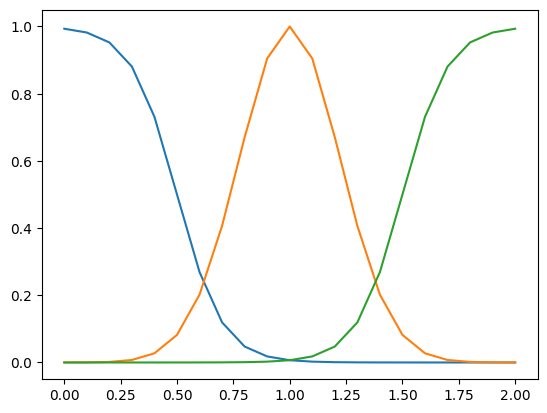

In [ ]:
# Define the universe of discourse for flood risk: Low (0), Medium (1), High (2)
flood_risk = Domain("Flood Risk", 0, 2, res=0.1)

flood_risk.low = sigmoid(1, -10, 0.5)
flood_risk.medium = gauss(c=1, b=10, c_m=1)
flood_risk.high = sigmoid(1, 10, 1.5)

flood_risk.low.plot()
flood_risk.medium.plot()
flood_risk.high.plot()

#### Fuzzy Rules

In [ ]:
# Bad condition: Severe combinations of flood hazard, precipitation, and heat.
def bad_weather_condition(f, h, p, flood_hazard, heat, precipitation):
    return fuzzy_OR(
        # HIGH FLOOD HAZARD
        fuzzy_AND(flood_hazard.high(f), precipitation.heavy(p)),
        fuzzy_AND(flood_hazard.high(f), precipitation.moderate(p)),
        fuzzy_AND(flood_hazard.high(f), precipitation.light(p)),

        fuzzy_AND(flood_hazard.high(f), precipitation.light(p), heat.danger(h)),
        fuzzy_AND(flood_hazard.high(f), precipitation.light(p), heat.caution(h)),

        # MODERATE FLOOD HAZARD
        fuzzy_AND(flood_hazard.medium(f), precipitation.heavy(p)),
        fuzzy_AND(flood_hazard.medium(f), precipitation.moderate(p)),

        fuzzy_AND(flood_hazard.medium(f), precipitation.light(p), heat.danger(h)),
        fuzzy_AND(flood_hazard.medium(f), precipitation.light(p), heat.caution(h)),

        # LOW FLOOD HAZARD
        fuzzy_AND(flood_hazard.low(f), precipitation.heavy(p)),

        fuzzy_AND(flood_hazard.low(f), precipitation.light(p), heat.danger(h)),
        fuzzy_AND(flood_hazard.low(f), precipitation.light(p), heat.caution(h))
    )


# Moderate condition: Intermediate risk with some caution needed.
def moderate_weather_condition(f, h, p, flood_hazard, heat, precipitation):
    return fuzzy_OR(
        # HIGH FLOOD HAZARD
        fuzzy_AND(flood_hazard.high(f), precipitation.light(p), heat.hazardous(h)),

        # MODERATE FLOOD HAZARD
        fuzzy_AND(flood_hazard.medium(f), precipitation.light(p), heat.hazardous(h)),
        fuzzy_AND(flood_hazard.medium(f), precipitation.moderate(p)),

        # LOW FLOOD HAZARD
        fuzzy_AND(flood_hazard.low(f), precipitation.light(p), heat.hazardous(h)),
        fuzzy_AND(flood_hazard.low(f), precipitation.moderate(p))
    )


# Good condition: Favorable combinations for normal activity.
def good_weather_condition(f, h, p, flood_hazard, heat, precipitation):
    return fuzzy_OR(
        # HIGH FLOOD HAZARD
        fuzzy_AND(flood_hazard.high(f), precipitation.light(p), heat.normal(h)),

        # MODERATE FLOOD HAZARD
        fuzzy_AND(flood_hazard.medium(f), precipitation.light(p), heat.normal(h)),

        # LOW FLOOD HAZARD
        fuzzy_AND(flood_hazard.low(f), precipitation.moderate(p)),
        fuzzy_AND(flood_hazard.low(f), precipitation.light(p), heat.normal(h))
    )

#### Fuzzy Function

In [ ]:
def fuzzy_weather_condition(f, h, p, flood_hazard, heat, precipitation):
  return (bad_weather_condition(f, h, p, flood_hazard, heat, precipitation),
          moderate_weather_condition(f, h, p, flood_hazard, heat, precipitation),
          good_weather_condition(f, h, p, flood_hazard, heat, precipitation))

### **II. Urban Density**

#### Fuzzy Sets

##### For Number of Key Areas

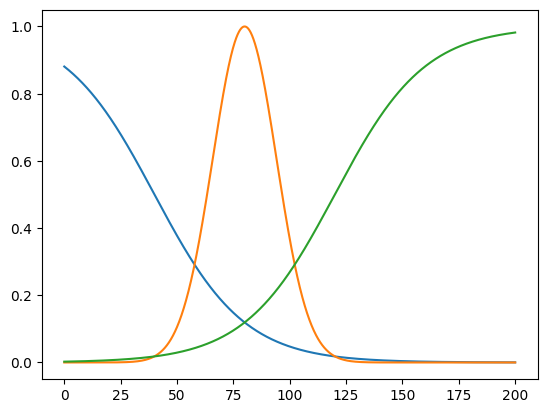

In [ ]:
# Define the domain (universe of discourse) for proximity to key areas (0-200)
key_areas = Domain("Key Areas", 0, 200, res=0.1)

# Define sigmoid membership functions for "few" and "many"
key_areas.few = sigmoid(L=1, k=-0.05, x0=40)        # Rising sigmoid centered at 40
key_areas.moderate = gauss(c=80, b=0.0025, c_m=1)   # Gaussian centered at 80
key_areas.many = sigmoid(L=1, k=0.05, x0=120)       # Falling sigmoid centered at 120

# Plot the membership functions
key_areas.few.plot()
key_areas.moderate.plot()
key_areas.many.plot()

# NOTE: There is no standard on this.

##### For Population

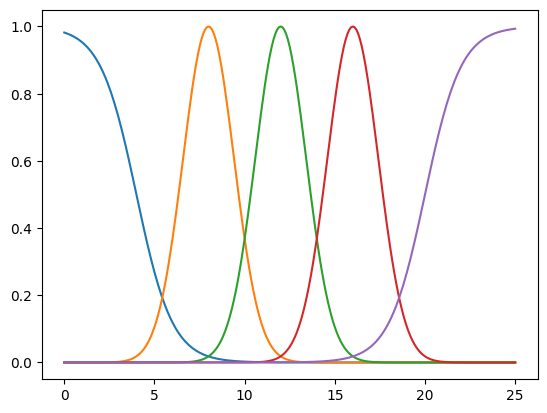

In [ ]:
# Define the domain (universe of discourse) for population (0-25)
population = Domain("Population", 0, 25, res=0.1)

# Define sigmoid functions for "very_low" and "very_high"
population.very_low = sigmoid(L=1, k=-1.0, x0=4)      # Rising sigmoid centered at 4
population.low = gauss(c=8, b=0.25, c_m=1)            # Gaussian centered at 8
population.moderate = gauss(c=12, b=0.25, c_m=1)      # Gaussian centered at 12
population.high = gauss(c=16, b=0.25, c_m=1)          # Gaussian centered at 16
population.very_high = sigmoid(L=1, k=1.0, x0=20)     # Falling sigmoid centered at 20

# Plot the membership functions
population.very_low.plot()
population.low.plot()
population.moderate.plot()
population.high.plot()
population.very_high.plot()


#### Fuzzy Rules

In [ ]:
def low_urban_density(a, p, key_areas, population):
    return fuzzy_OR(
        # Few key areas
        fuzzy_AND(key_areas.few(a), population.very_low(p)),
        fuzzy_AND(key_areas.few(a), population.low(p)),
        fuzzy_AND(key_areas.few(a), population.moderate(p)),

        # Moderate key areas
        fuzzy_AND(key_areas.moderate(a), population.very_low(p)),
        fuzzy_AND(key_areas.moderate(a), population.low(p)),

        # Many key areas
        # no case for that
    )


def moderate_urban_density(a, p, key_areas, population):
    return fuzzy_OR(
        # Few key areas
        fuzzy_AND(key_areas.few(a), population.high(p)),
        fuzzy_AND(key_areas.few(a), population.very_high(p)),

        # Moderate key areas
        fuzzy_AND(key_areas.moderate(a), population.moderate(p)),

        # Many key areas
        # no case for that
    )


def high_urban_density(a, p, key_areas, population):
    return fuzzy_OR(
        # Few key areas
        # no case for that

        # Moderate key areas
        fuzzy_AND(key_areas.moderate(a), population.high(p)),
        fuzzy_AND(key_areas.moderate(a), population.very_high(p)),

        # Many key areas
        fuzzy_AND(key_areas.many(a), population.low(p)),
        fuzzy_AND(key_areas.many(a), population.moderate(p)),
        fuzzy_AND(key_areas.many(a), population.high(p)),
        fuzzy_AND(key_areas.many(a), population.very_high(p))
    )

#### Fuzzy Function

In [ ]:
def fuzzy_urban_density(a, p, key_areas, population):
  return (low_urban_density(a, p, key_areas, population),
          moderate_urban_density(a, p, key_areas, population),
          high_urban_density(a, p, key_areas, population))

### **III. Sidewalk Capacity**

#### Fuzzy Sets

##### For Walkway Width

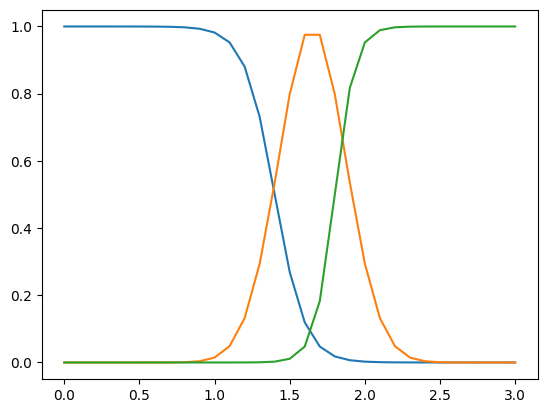

In [ ]:
walkway_width = Domain("walkway_width", 0, 3, res=0.1)

walkway_width.narrow = sigmoid(1, -10, 1.4)
walkway_width.midsize = gauss(c=1.65, b=10, c_m=1)
walkway_width.wide = sigmoid(1, 15, 1.8)

walkway_width.narrow.plot()
walkway_width.midsize.plot()
walkway_width.wide.plot()

##### For Zoning Area

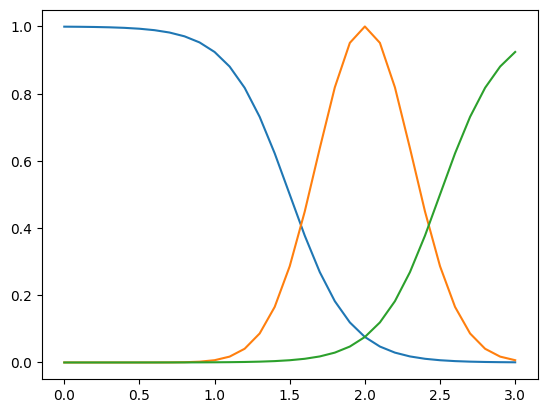

In [ ]:
zoning_area = Domain("zoning_area", 0, 3, res=0.1)

zoning_area.commercial = sigmoid(1, -5, 1.5)
zoning_area.residential = gauss(c=2, b=5, c_m=1)
zoning_area.industrial = sigmoid(1, 5, 2.5)

zoning_area.commercial.plot()
zoning_area.residential.plot()
zoning_area.industrial.plot()

#### Fuzzy Rules

In [ ]:
def low_sidewalk_capacity(w, z, walkway_width, zoning_area):
    return fuzzy_OR(
        # Rule 1: Narrow walkway, commercial area
        fuzzy_AND(walkway_width.narrow(w), zoning_area.commercial(z))
    )

def moderate_sidewalk_capacity(w, z, walkway_width, zoning_area):
    return fuzzy_OR(
        # Rule 1: Midsize walkway, commercial area
        fuzzy_AND(walkway_width.midsize(w), zoning_area.commercial(z)),

        # Rule 2: Narrow walkway, industrial area
        fuzzy_AND(walkway_width.narrow(w), zoning_area.industrial(z)),

        # Rule 3: Midsize walkway, industrial area
        fuzzy_AND(walkway_width.midsize(w), zoning_area.industrial(z)),

        # Rule 4: Narrow walkway, residential area
        fuzzy_AND(walkway_width.narrow(w), zoning_area.residential(z))
    )

def high_sidewalk_capacity(w, z, walkway_width, zoning_area):
    return fuzzy_OR(
        # Rule 1: Wide walkway, commercial area
        fuzzy_AND(walkway_width.wide(w), zoning_area.commercial(z)),

        # Rule 2: Wide walkway, industrial area
        fuzzy_AND(walkway_width.wide(w), zoning_area.industrial(z)),

        # Rule 3: Midsize walkway, residential area
        fuzzy_AND(walkway_width.midsize(w), zoning_area.residential(z)),

        # Rule 4: Wide walkway, residential area
        fuzzy_AND(walkway_width.wide(w), zoning_area.residential(z))
    )

In [ ]:
# PUD1 and City Core needs to be wide. Separate.

#### Fuzzy Function

In [ ]:
def fuzzy_sidewalk_capacity(w, z, walkway_width, zoning_area):
    return (low_sidewalk_capacity(w, z, walkway_width, zoning_area),
            moderate_sidewalk_capacity(w, z, walkway_width, zoning_area),
            high_sidewalk_capacity(w, z, walkway_width, zoning_area))

### **IV. Safety Risk**

#### Fuzzy Sets

##### For Gradient

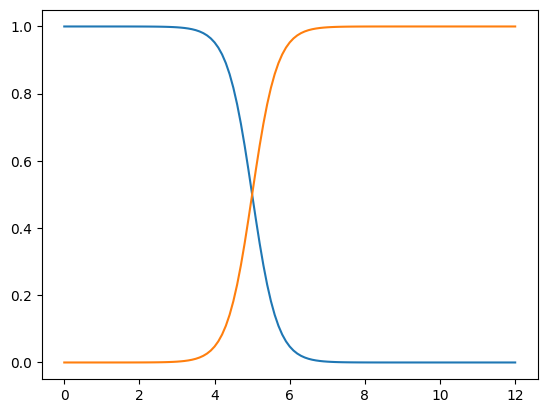

In [ ]:
gradient = Domain("gradient", 0, 12, res=0.1)

gradient.accessible = sigmoid(1, -3, 5)
gradient.inaccessible = sigmoid(1, 3, 5)

gradient.accessible.plot()
gradient.inaccessible.plot()

##### For Surface

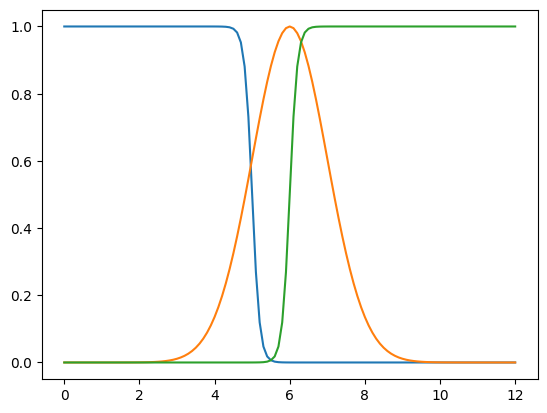

In [ ]:
surface = Domain("surface", 0, 12, res=0.1)

surface.smooth = sigmoid(1, -10, 5)
surface.cracked = gauss(c=6, b=0.5, c_m=1)
surface.damaged = sigmoid(1, 10, 6)

surface.smooth.plot()
surface.cracked.plot()
surface.damaged.plot()

##### For the Presence of Street Furniture

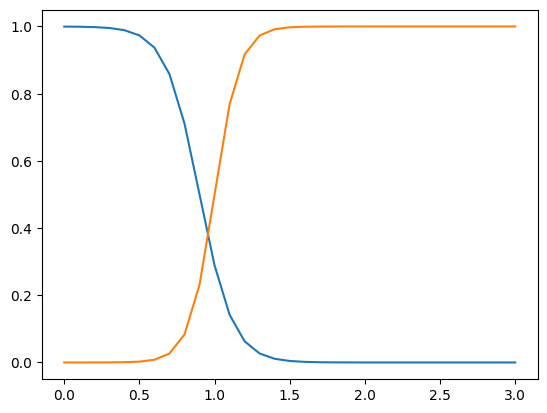

In [ ]:
street_furniture = Domain("street_furniture", 0, 3, res=0.1)

street_furniture.obstructs = sigmoid(1, -9, 0.9)
street_furniture.does_not_obstruct = sigmoid(1, 12, 1)

street_furniture.obstructs.plot()
street_furniture.does_not_obstruct.plot()

##### For Border Buffer

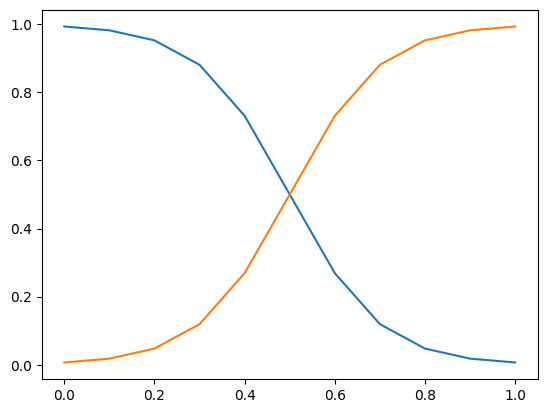

In [ ]:
border_buffer = Domain("border_buffer", 0, 1, res=0.1)

border_buffer.exists = sigmoid(1, -10, 0.5)
border_buffer.does_not_exist = sigmoid(1, 10, 0.5)

border_buffer.exists.plot()
border_buffer.does_not_exist.plot()

##### For Lighting

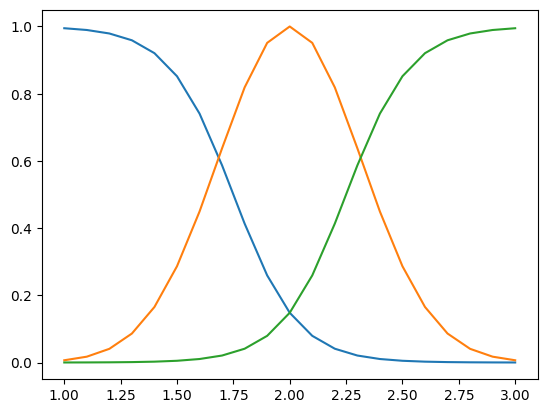

In [ ]:
lighting = Domain("lighting", 1, 3, res=0.1)

lighting.poor = sigmoid(1, -7, 1.75)
lighting.adequate = gauss(c=2, b=5, c_m=1)
lighting.excellent = sigmoid(1, 7, 2.25)

lighting.poor.plot()
lighting.adequate.plot()
lighting.excellent.plot()

##### For Time

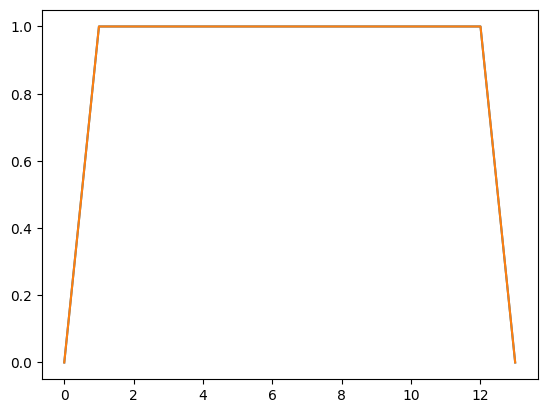

In [ ]:
time = Domain("time", 0, 13, res=0.1)  # Domain covering 24 hours

time.day = trapezoid(0, 1, 12, 13)  # 5 am = 0, 6 am = 1, 5 pm = 12, 6 pm = 13
time.night = trapezoid(0, 1, 12, 13)  # 5 pm = 0, 6 pm = 1, 5 am = 12, 6 am = 13

# Plot the membership functions
time.day.plot()
time.night.plot()

In [ ]:
def preprocess_time(t):
    if t >= 6 and t <= 17:  # 6 am to 5 pm
        t_day = t - 5
        t_night = 0
    elif t >= 18:            # beyond 6 pm
        t_day = 0
        t_night = t - 17
    elif t <= 5:             # before 5 am
        t_day = 0
        t_night = t + 7
    else:                    # 5 am to 6 am
        t_day = t - 5
        t_night = t - 17

    return t_day, t_night

#### Fuzzy Rules for Lighting using Light Intensity and Time

In [ ]:
def bad_lighting_score(l, t, lighting, time):
    t_day, t_night = preprocess_time(t)

    return fuzzy_OR(
        # Night, Poor Lighting
        fuzzy_AND(time.night(t_night), lighting.poor(l))
    )

def moderate_lighting_score(l, t, lighting, time):
    t_day, t_night = preprocess_time(t)

    return fuzzy_OR(
        # Night, Adequate Lighting
        fuzzy_AND(time.night(t_night), lighting.adequate(l))
    )

def good_lighting_score(l, t, lighting, time):
    t_day, t_night = preprocess_time(t)

    return fuzzy_OR(
        # Day, Excellent Lighting
        fuzzy_AND(time.day(t_day), lighting.excellent(l)),
        # Day, Poor Lighting
        fuzzy_AND(time.day(t_day), lighting.poor(l)),
        # Day, Adequate Lighting
        fuzzy_AND(time.day(t_day), lighting.adequate(l)),
        # Night, Excellent Lighting
        fuzzy_AND(time.night(t_night), lighting.excellent(l)),
    )

In [ ]:
from types import SimpleNamespace

def calculate_lighting_score(l, t, lighting, time):
    # Compute each score using your defined functions
    bad = bad_lighting_score(l, t, lighting, time)
    moderate = moderate_lighting_score(l, t, lighting, time)
    good = good_lighting_score(l, t, lighting, time)

    # Create an object with dot-accessible attributes
    lighting_score = SimpleNamespace(bad=bad, moderate=moderate, good=good)
    return lighting_score


#### Fuzzy Rules

In [ ]:
def low_safety_risk(g, s, sf, bb, gradient, surface, street_furniture, lighting_score, border_buffer):
  return fuzzy_OR(
      # Rule 1: Accessible	Smooth	Does not obstruct	Exists	Good
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 2: Accessible	Smooth	Does not obstruct	Does not Exist	Good
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 3: Accessible	Cracked	Does not obstruct	Exists	Good
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 4: Accessible	Cracked	Does not obstruct	Does not Exist	Good
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 5: Inacessible	Smooth	Does not obstruct	Exists	Good
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 6: Inacessible	Cracked	Does not obstruct	Exists	Good
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.good),
  )

In [ ]:
def moderate_safety_risk(g, s, sf, bb, gradient, surface, street_furniture, lighting_score, border_buffer):
  return fuzzy_OR(
      # Rule 1: Accessible	Smooth	Obstructs	Exists	Good
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 2: Accessible	Smooth	Obstructs	Exists	Moderate
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 3: Accessible	Smooth	Obstructs	Does not Exist	Good
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 4: Accessible	Smooth	Does not obstruct	Exists	Moderate
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 5: Accessible	Smooth	Does not obstruct	Does not Exist	Moderate
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 6: Accessible	Cracked	Obstructs	Exists	Good
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 7: Accessible	Cracked	Does not obstruct	Exists	Moderate
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 8: Accessible	Cracked	Does not obstruct	Does not Exist	Moderate
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 9: Accessible	Damaged	Does not obstruct	Exists	Good
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 10: Accessible	Damaged	Does not obstruct	Exists	Moderate
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 11: Accessible	Damaged	Does not obstruct	Does not Exist	Good
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 12: Inacessible	Smooth	Obstructs	Exists	Good
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 13: Inacessible	Smooth	Does not obstruct	Exists	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 14: Inacessible	Smooth	Does not obstruct	Does not Exist	Good
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 15: Inacessible	Cracked	Obstructs	Exists	Good
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 16: Inacessible	Cracked	Does not obstruct	Exists	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 17: Inacessible	Cracked	Does not obstruct	Does not Exist	Good
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 18: Inacessible	Damaged	Does not obstruct	Exists	Good
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.good),
  )

In [ ]:
def high_safety_risk(g, s, sf, bb, gradient, surface, street_furniture, lighting_score, border_buffer):
  return fuzzy_OR(
      # Rule 1: Accessible	Smooth	Obstructs	Exists	Bad
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 2: Accessible	Smooth	Obstructs	Does not Exist	Moderate
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 3: Accessible	Smooth	Obstructs	Does not Exist	Bad
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 4: Accessible	Smooth	Does not obstruct	Exists	Bad
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 5: Accessible	Smooth	Does not obstruct	Does not Exist	Bad
      fuzzy_AND(gradient.accessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 6: Accessible Cracked Obstructs Exists Moderate
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 7: Accessible	Cracked	Obstructs	Exists	Bad
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 8: Accessible	Cracked	Obstructs	Does not Exist	Good
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 9: Accessible	Cracked	Obstructs	Does not Exist	Moderate
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 10: Accessible	Cracked	Obstructs	Does not Exist	Bad
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 11: Accessible	Cracked	Does not obstruct	Exists	Bad
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 12: Accessible	Cracked	Does not obstruct	Does not Exist	Bad
      fuzzy_AND(gradient.accessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 13: Accessible	Damaged	Obstructs	Exists	Good
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 14: Accessible	Damaged	Obstructs	Exists	Moderate
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 15: Accessible	Damaged	Obstructs	Exists	Bad
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 16: Accessible	Damaged	Obstructs	Does not Exist	Good
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 17: Accessible	Damaged	Obstructs	Does not Exist	Moderate
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 18: Accessible	Damaged	Obstructs	Does not Exist	Bad
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 19: Accessible	Damaged	Does not obstruct	Exists	Bad
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 20: Accessible	Damaged	Does not obstruct	Does not Exist	Moderate
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 21: Accessible	Damaged	Does not obstruct	Does not Exist	Bad
      fuzzy_AND(gradient.accessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 22: Inacessible	Smooth	Obstructs	Exists	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 23: Inacessible	Smooth	Obstructs	Exists	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 24: Inacessible	Smooth	Obstructs	Does not Exist	Good
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 25: Inacessible	Smooth	Obstructs	Does not Exist	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 26: Inacessible	Smooth	Obstructs	Does not Exist	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 27: Inacessible	Smooth	Does not obstruct	Exists	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 28: Inacessible	Smooth	Does not obstruct	Does not Exist	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 29: Inacessible	Smooth	Does not obstruct	Does not Exist	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.smooth(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 30: Inacessible	Cracked	Obstructs	Exists	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 31: Inacessible	Cracked	Obstructs	Exists	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 32: Inacessible	Cracked	Obstructs	Does not Exist	Good
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 33: Inacessible	Cracked	Obstructs	Does not Exist	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 34: Inacessible	Cracked	Obstructs	Does not Exist	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 35: Inacessible	Cracked	Does not obstruct	Exists	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 36: Inacessible	Cracked	Does not obstruct	Does not Exist	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 37: Inacessible	Cracked	Does not obstruct	Does not Exist	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.cracked(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 38: Inacessible	Damaged	Obstructs	Exists	Good
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.good),

      # Rule 39: Inacessible	Damaged	Obstructs	Exists	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 40: Inacessible	Damaged	Obstructs	Exists	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 41: Inacessible	Damaged	Obstructs	Does not Exist	Good
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 42: Inacessible	Damaged	Obstructs	Does not Exist	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 43: Inacessible	Damaged	Obstructs	Does not Exist	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.obstructs(sf), border_buffer.does_not_exist(bb), lighting_score.bad),

      # Rule 44: Inacessible	Damaged	Does not obstruct	Exists	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.moderate),

      # Rule 45: Inacessible	Damaged	Does not obstruct	Exists	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.exists(bb), lighting_score.bad),

      # Rule 46: Inacessible	Damaged	Does not obstruct	Does not Exist	Good
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.good),

      # Rule 47: Inacessible	Damaged	Does not obstruct	Does not Exist	Moderate
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.moderate),

      # Rule 48: Inacessible	Damaged	Does not obstruct	Does not Exist	Bad
      fuzzy_AND(gradient.inaccessible(g), surface.damaged(s), street_furniture.does_not_obstruct(sf), border_buffer.does_not_exist(bb), lighting_score.bad),
  )

#### Fuzzy Function

In [ ]:
def fuzzy_safety_risk(g, s, sf, l, bb, t, gradient, surface, street_furniture, lighting, border_buffer, time):
  lighting_score = calculate_lighting_score(l, t, lighting, time)

  return (low_safety_risk(g, s, sf, bb, gradient, surface, street_furniture, lighting_score, border_buffer),
          moderate_safety_risk(g, s, sf, bb, gradient, surface, street_furniture, lighting_score, border_buffer),
          high_safety_risk(g, s, sf, bb, gradient, surface, street_furniture, lighting_score, border_buffer))

### **V. Accessibility**

#### Fuzzy Rules

In [ ]:
def accessible (weather_condition,  urban_density, road_capacity, safety_level):
    '''
        Params:
          weather_condition should have three values: good, moderate, bad
          urban_density should have three values: low, moderate, high
          road_capacity should have three values: low, moderate, high
          safety_level should have three values: low, moderate, high

        These values are pre-computed using the sub FIS
    '''

    return fuzzy_OR(
        # WEATHER CONDITION = GOOD

            # URBAN DENSITY = HIGH
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.high, safety_level.moderate),
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.moderate, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.moderate, safety_level.moderate),
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.moderate, safety_level.high),

            # URBAN DENSITY = MODERATE
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.high, safety_level.moderate),
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.moderate, safety_level.moderate),

            # URBAN DESNITY = LOW
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.high, safety_level.moderate),
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.moderate, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.moderate, safety_level.moderate),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.low, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.low, safety_level.moderate),


        # WEATHER CONDITION = MODERATE

            # URBAN DENSITY = HIGH
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.high, safety_level.moderate),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.moderate, safety_level.low),

            # URBAN DENSITY = MODERATE
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.high, safety_level.moderate),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.moderate, safety_level.moderate),

            # URBAN DENSITY = LOW
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.high, safety_level.moderate),
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.moderate, safety_level.low),
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.moderate, safety_level.moderate),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.moderate, safety_level.low),
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.low, safety_level.moderate),

        # WEATHER CONDITION = BAD

            # URBAN DENSITY = HIGH
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.high, safety_level.low),

            # URBAN DENSITY = MODERATE
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.high, safety_level.moderate),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.moderate, safety_level.low),

            # URBAN DENSITY = LOW
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.high, safety_level.low),
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.high, safety_level.moderate),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.moderate, safety_level.low),
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.moderate, safety_level.moderate),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.low, safety_level.low)
    )


def not_accessible(weather_condition, urban_density, road_capacity, safety_level):
    return fuzzy_OR(
        # WEATHER CONDITION = GOOD

            # URBAN DENSITY = HIGH
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.low, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.low, safety_level.moderate),
        fuzzy_AND(weather_condition.good, urban_density.high, road_capacity.low, safety_level.high),

            # URBAN DENSITY = MODERATE
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.moderate, safety_level.high),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.low, safety_level.low),
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.low, safety_level.moderate),
        fuzzy_AND(weather_condition.good, urban_density.moderate, road_capacity.low, safety_level.high),

            # URBAN DENSITY = LOW
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.moderate, safety_level.high),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.good, urban_density.low, road_capacity.low, safety_level.high),

        # WEATHER CONDITION = MODERATE

            # URBAN DENSITY = HIGH
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.moderate, safety_level.moderate),
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.moderate, safety_level.high),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.low, safety_level.low),
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.low, safety_level.moderate),
        fuzzy_AND(weather_condition.moderate, urban_density.high, road_capacity.low, safety_level.high),

            # URBAN DENSITY = MODERATE
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.moderate, safety_level.high),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.low, safety_level.low),
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.low, safety_level.moderate),
        fuzzy_AND(weather_condition.moderate, urban_density.moderate, road_capacity.low, safety_level.high),

            # URBAN DENSITY = LOW
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.moderate, safety_level.high),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.moderate, urban_density.low, road_capacity.low, safety_level.high),

        # WEATHER CONDITION = BAD

            # URBAN DENSITY = HIGH
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.high, safety_level.moderate),
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.moderate, safety_level.low),
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.moderate, safety_level.moderate),
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.moderate, safety_level.high),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.low, safety_level.low),
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.low, safety_level.moderate),
        fuzzy_AND(weather_condition.bad, urban_density.high, road_capacity.low, safety_level.high),

            # URBAN DENSITY = MODERATE
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.moderate, safety_level.moderate),
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.moderate, safety_level.high),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.low, safety_level.low),
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.low, safety_level.moderate),
        fuzzy_AND(weather_condition.bad, urban_density.moderate, road_capacity.low, safety_level.high),

            # URBAN DENSITY = LOW
                # ROAD CAPACITY = HIGH
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.high, safety_level.high),
                # ROAD CAPACITY = MODERATE
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.moderate, safety_level.high),
                # ROAD CAPACITY = LOW
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.low, safety_level.moderate),
        fuzzy_AND(weather_condition.bad, urban_density.low, road_capacity.low, safety_level.high)
    )

#### Fuzzy Functions

In [ ]:
def classify(fuzzy_tup):
    arg_max_idx = np.argmax(fuzzy_tup)
    result = np.zeros(shape=(len(fuzzy_tup), ))
    result[arg_max_idx] = 1
    return tuple(result)

def fuzzy_accessibility(weather_condition_tup, urban_density_tup, sidewalk_capacity_tup, safety_level_tup):
    return (accessible(weather_condition_tup, urban_density_tup, sidewalk_capacity_tup, safety_level_tup),
            not_accessible(weather_condition_tup, urban_density_tup, sidewalk_capacity_tup, safety_level_tup))

## **Classification Models**

### **Logistic Regressor Model**


#### Split training and testing data

In [ ]:
# Function to split features and target
def split_features_target(df, test_size):

  """
  df should contain these columns ['Weather Conditions', 'Road Capacity', 'Urban Density', 'Safety Risk', 'Accessibility']
  """

  cols = df.columns
  print(cols)

  classes = cols[-1:]  # Target is 'Accessibility'
  print(classes)
  features = cols[0:4]  # Select the first 4 features
  print(features)

  X = df[features].values
  Y = df[classes].values

  return train_test_split(X, Y, test_size=test_size)

#### Logistic Regression Model

In [ ]:
# Function to train and evaluate the logistic regression model
def train_logistic_regression(X_train, X_test, Y_train, Y_test):
  log_accessibility_model = LogisticRegression(penalty="l2").fit(X_train, Y_train)
  score = log_accessibility_model.score(X_test, Y_test)
  return log_accessibility_model, score

### Get accessibility score probability

In [ ]:
# Function to get predicted probabilities
def get_probabilities(model, val):
  return model.predict_proba(val)

In [ ]:
n_samples = 20000

# Generate random values for weather
f = np.random.choice([0, 1, 2], n_samples)  # Discrete values for f (0, 1, 2)
h = np.random.uniform(0, 60, n_samples)     # Continuous values for h (0-60)
p = np.random.uniform(0, 15, n_samples)     # Continuous values for p (0-15)

# Generate random values for urban density
ka = np.random.uniform(0, 200, n_samples)
pop = np.random.uniform(0, 25, n_samples)

# Generate random vlaues for safety risk
w = np.random.uniform(0, 3, n_samples)
z = np.random.uniform(0, 3, n_samples)

# Generate random values for safety risk
g = np.random.uniform(0, 12, n_samples)
s = np.random.uniform(0, 12, n_samples)
sf = np.random.uniform(0, 3, n_samples)
bb = np.random.choice([0, 1], n_samples)
l = np.random.choice([1, 2 ,3], n_samples)
t= np.random.uniform(0, 24, n_samples)

In [ ]:
# Generate fuzzy and defuzzified values for weather condition
fuzz_weather_condition = [fuzzy_weather_condition(f[i], h[i], p[i], flood_risk, heat, precipitation) for i in range(n_samples)]
fuzz_urban_density = [fuzzy_urban_density(ka[i], pop[i], key_areas, population) for i in range(n_samples)]
fuzz_sidewalk_capacity = [fuzzy_sidewalk_capacity(w[i], z[i], walkway_width, zoning_area) for i in range(n_samples)]
fuzz_safety_risk = [fuzzy_safety_risk(g[i], s[i], sf[i], l[i], bb[i], t[i], gradient, surface, street_furniture, lighting, border_buffer, time) for i in range(n_samples)]

In [ ]:
# Initialize an empty DataFrame
df = pd.DataFrame(columns=['weather_condition', 'urban_density', 'sidewalk_capacity', 'safety_risk', 'accessibility'])

# Initialize a list to store the rows
data = []

# Loop through samples and calculate fuzzy values, then store in DataFrame
for i in range(n_samples):
  # Calculate fuzzy values for each aspect
  bad_weather_condition, moderate_weather_condition, good_weather_condition = fuzz_weather_condition[i]
  low_urban_density, moderate_urban_density, high_urban_density = fuzz_urban_density[i]
  low_sidewalk_capacity, moderate_sidewalk_capacity, high_sidewalk_capacity = fuzz_sidewalk_capacity[i]
  low_safety_risk, moderate_safety_risk, high_safety_risk = fuzz_safety_risk[i]

  crisp_weather_condition = defuzzify(fuzz_weather_condition[i])
  crisp_urban_density = defuzzify(fuzz_urban_density[i])
  crisp_sidewalk_capacity = defuzzify(fuzz_sidewalk_capacity[i])
  crisp_safety_risk = defuzzify(fuzz_safety_risk[i])

  # Classify accessibility using the fuzzy values
  accessibility = classify(fuzzy_accessibility(
      weather_condition_tup=SimpleNamespace(
          bad=bad_weather_condition,
          moderate=moderate_weather_condition,
          good=good_weather_condition),
      urban_density_tup=SimpleNamespace(
          low=low_urban_density,
          moderate=moderate_urban_density,
          high=high_urban_density),
      sidewalk_capacity_tup=SimpleNamespace(
          low=low_sidewalk_capacity,
          moderate=moderate_sidewalk_capacity,
          high=high_sidewalk_capacity),
      safety_level_tup=SimpleNamespace(
          low=low_safety_risk,
          moderate=moderate_safety_risk,
          high=high_safety_risk)
  ))

  # Store the defuzzified values and accessibility in the data list
  data.append({
      'weather_condition': crisp_weather_condition,
      'urban_density': crisp_urban_density,
      'sidewalk_capacity': crisp_sidewalk_capacity,
      'safety_risk': crisp_safety_risk,
      'accessibility': np.argmax(accessibility)   # NOTE THIS SINCE FUNCTION RETURNS MEMBERSHIPS
  })

# Create the DataFrame from the list of dictionaries
df = pd.DataFrame(data)

# Output the final DataFrame with only defuzzified values
df


,weather_condition,urban_density,sidewalk_capacity,safety_risk,accessibility
0,0.004725,24.987394,71.603167,3.868415,0
1,1.760401,30.873965,97.228762,99.667612,1
2,0.000096,26.097346,47.891504,85.305100,1
3,0.004156,36.569347,98.835724,97.099201,1
4,99.646768,57.087249,37.843958,89.648415,0
...,...,...,...,...,...
19995,0.002301,26.422173,100.000000,64.470077,0
19996,0.002660,51.787360,55.213024,36.683586,0
19997,0.001373,39.482998,100.000000,0.000862,0
19998,0.002301,81.966116,21.392775,90.101790,1


Index(['weather_condition', 'urban_density', 'sidewalk_capacity',
       'safety_risk', 'accessibility'],
      dtype='object')
Index(['accessibility'], dtype='object')
Index(['weather_condition', 'urban_density', 'sidewalk_capacity',
       'safety_risk'],
      dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


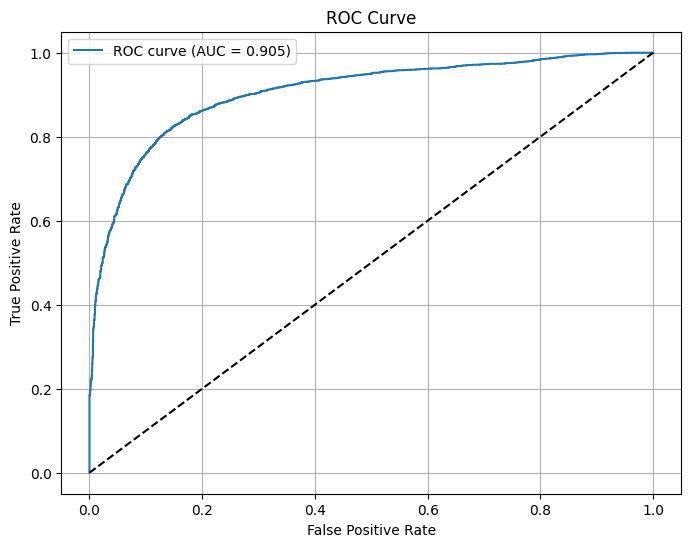

<Figure size 800x600 with 0 Axes>

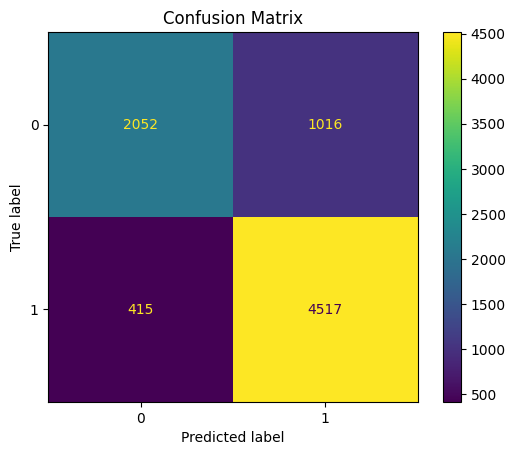

In [ ]:
#Naive Bayes Classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    roc_curve
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Split the data into features and target
X = df[['weather_condition', 'urban_density', 'sidewalk_capacity', 'safety_risk']].values
y = df['accessibility'].values  # 0 or 1

# Train-test split
X_train, X_test, y_train, y_test = split_features_target(df, 0.40)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build and train Gaussian Naive Bayes Classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Get predictions and probability scores
y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)[:, 1]  # Probability scores for positive class

# Calculate all metrics
metrics = {
    'AUC': np.round(roc_auc_score(y_test, y_prob), 3),
    'Precision': np.round(precision_score(y_test, y_pred), 3),
    'Recall': np.round(recall_score(y_test, y_pred), 3),
    'F1-score': np.round(f1_score(y_test, y_pred), 3),
    'Accuracy': np.round(accuracy_score(y_test, y_pred), 3)
}

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {metrics["AUC"]})')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(8, 6))
disp.plot()
plt.title('Confusion Matrix')

plt.show()

In [ ]:
prob_in_class_1_given_X = np.exp(np.round(gnb.predict_proba(X_test)[:, 1], 3))

In [ ]:
prob_in_class_1_given_X

array([2.37500609, 2.59607321, 2.29790997, ..., 1.12187344, 1.62742661,
       2.59607321])

In [ ]:
# Print all metrics
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value}")

AUC: 0.905
Precision: 0.816
Recall: 0.916
F1-score: 0.863
Accuracy: 0.821


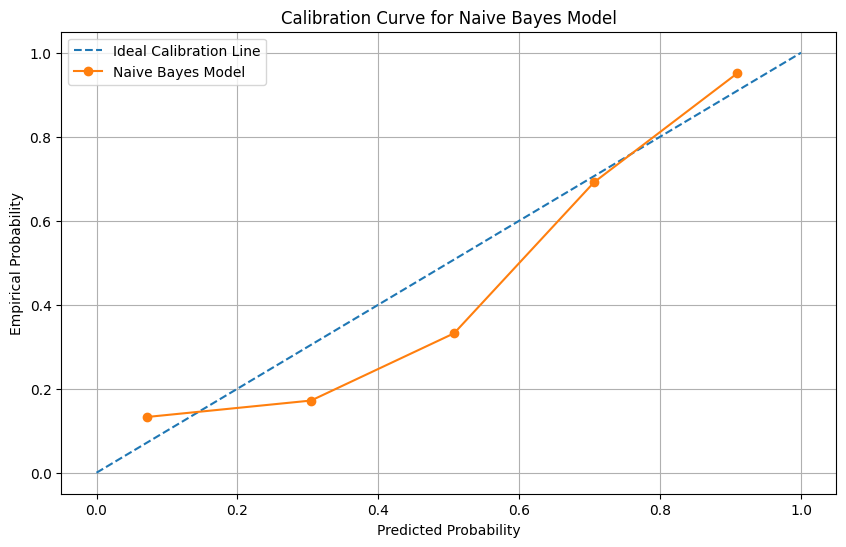

In [ ]:
from sklearn.calibration import calibration_curve

# Generate calibration data
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=5)

# Plot the calibration curve
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Ideal Calibration Line")  # Diagonal for perfect calibration
plt.plot(prob_pred, prob_true, marker='o', label="Naive Bayes Model")

# Label the plot
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.title("Calibration Curve for Naive Bayes Model")
plt.legend()
plt.grid(True)
plt.show()

### **Neural Network Model**

In [ ]:
pip install torch pandas scikit-learn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assume your DataFrame `df` is already created with 5 columns

# Split the data into features and target
X = df[['weather_condition', 'urban_density', 'sidewalk_capacity', 'safety_risk']].values
y = df['accessibility'].values  # 0 or 1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Shape (n_samples, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Define the larger neural network
class LargerNN(nn.Module):
    def __init__(self):
        super(LargerNN, self).__init__()
        self.fc1 = nn.Linear(4, 256)    # Increased input layer to 256 neurons
        self.fc2 = nn.Linear(256, 128)  # Second layer with 128 neurons
        self.fc3 = nn.Linear(128, 64)   # Third layer with 64 neurons
        self.fc4 = nn.Linear(64, 32)    # Fourth layer with 32 neurons
        self.fc5 = nn.Linear(32, 16)    # Fifth layer with 16 neurons
        self.fc6 = nn.Linear(16, 8)     # Sixth layer with 8 neurons
        self.fc7 = nn.Linear(8, 4)      # Seventh layer with 4 neurons
        self.fc8 = nn.Linear(4, 1)      # Output layer for binary classification
        self.dropout = nn.Dropout(0.3)  # Increased dropout rate to 30%

    def forward(self, x):
        x = torch.relu(self.fc1(x))    # Activation for first layer
        x = self.dropout(x)            # Apply dropout
        x = torch.relu(self.fc2(x))    # Activation for second layer
        x = self.dropout(x)            # Apply dropout
        x = torch.relu(self.fc3(x))    # Activation for third layer
        x = self.dropout(x)            # Apply dropout
        x = torch.relu(self.fc4(x))    # Activation for fourth layer
        x = self.dropout(x)            # Apply dropout
        x = torch.relu(self.fc5(x))    # Activation for fifth layer
        x = self.dropout(x)            # Apply dropout
        x = torch.relu(self.fc6(x))    # Activation for sixth layer
        x = self.dropout(x)            # Apply dropout
        x = torch.relu(self.fc7(x))    # Activation for seventh layer
        x = self.fc8(x)                # Output layer without activation
        return x

# Initialize the model, loss function, and optimizer
model = LargerNN()
criterion = nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 500
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate on the test data
with torch.no_grad():
    test_outputs = torch.sigmoid(model(X_test_tensor))  # Apply sigmoid to get probabilities
    predicted = (test_outputs >= 0.5).float()  # Convert probabilities to 0 or 1
    accuracy = (predicted == y_test_tensor).float().mean().item()
    print(f'Test Accuracy: {accuracy * 100:.2f}%')


Epoch [10/500], Loss: 0.6785
Epoch [20/500], Loss: 0.6691
Epoch [30/500], Loss: 0.6391
Epoch [40/500], Loss: 0.5476
Epoch [50/500], Loss: 0.4588
Epoch [60/500], Loss: 0.4158
Epoch [70/500], Loss: 0.3953
Epoch [80/500], Loss: 0.3754
Epoch [90/500], Loss: 0.3678
Epoch [100/500], Loss: 0.3606
Epoch [110/500], Loss: 0.3490
Epoch [120/500], Loss: 0.3465
Epoch [130/500], Loss: 0.3400
Epoch [140/500], Loss: 0.3374
Epoch [150/500], Loss: 0.3337
Epoch [160/500], Loss: 0.3312
Epoch [170/500], Loss: 0.3258
Epoch [180/500], Loss: 0.3300
Epoch [190/500], Loss: 0.3291
Epoch [200/500], Loss: 0.3246
Epoch [210/500], Loss: 0.3258
Epoch [220/500], Loss: 0.3260
Epoch [230/500], Loss: 0.3220
Epoch [240/500], Loss: 0.3194
Epoch [250/500], Loss: 0.3194
Epoch [260/500], Loss: 0.3180
Epoch [270/500], Loss: 0.3170
Epoch [280/500], Loss: 0.3136
Epoch [290/500], Loss: 0.3145
Epoch [300/500], Loss: 0.3161
Epoch [310/500], Loss: 0.3134
Epoch [320/500], Loss: 0.3115
Epoch [330/500], Loss: 0.3114
Epoch [340/500], Lo

In [ ]:
import torch

# Assuming your DataFrame df is defined and the model has been trained
# Select 10 random rows from the DataFrame
sample_df = df.sample(n=10, random_state=42)  # You can set a different seed for randomness

# Prepare the features for prediction
X_sample = sample_df[['weather_condition', 'urban_density', 'sidewalk_capacity', 'safety_risk']].values

# Standardize the features using the scaler
X_sample = scaler.transform(X_sample)

# Convert to PyTorch tensor
X_sample_tensor = torch.tensor(X_sample, dtype=torch.float32)

# Make predictions
with torch.no_grad():
    sample_outputs = torch.sigmoid(model(X_sample_tensor))  # Apply sigmoid to get probabilities
    predicted_accessibility = (sample_outputs >= 0.5).float()  # Convert probabilities to 0 or 1

# Display the results
sample_df['predicted_accessibility'] = predicted_accessibility.numpy()  # Add predictions to the DataFrame
print(sample_df[['weather_condition', 'urban_density', 'sidewalk_capacity', 'safety_risk', 'predicted_accessibility']])


       weather_condition  urban_density  sidewalk_capacity  safety_risk  \
10650          92.637730      55.074594           0.796916    49.694221   
2041           32.803574      26.858895         100.000000    99.665357   
8668            0.089005      38.999784          84.691213    86.537669   
1114            2.453177      43.829711          24.078095    78.695961   
13902           2.660553       0.766932         100.000000   100.000000   
11963           0.084367      95.684839           4.064695    49.778311   
11072           1.248645       0.576354          66.392747    80.528961   
3002           16.749251      28.985597          12.287669    98.485420   
19771           3.028041       8.996170          35.048838    50.339152   
8115           48.702850      83.859181          28.561468    72.744395   

       predicted_accessibility  
10650                      1.0  
2041                       1.0  
8668                       1.0  
1114                       1.0  
13902    

In [ ]:
# Save the model's state_dict to a .pth file
torch.save(model.state_dict(), 'nn_model.pth')
print("Model state_dict saved to nn_model.pth")


Model state_dict saved to nn_model.pth


### **Naive Bayes Model**

# **Test Area**

## Weather Condition Test

In [ ]:
# Function use for weather condition

f = 2   # flood risk
h = 24  # heat
p = 8   # precipitation

print(fuzzy_weather_condition(f, h, p, flood_risk, heat, precipitation))
print(defuzzify(fuzzy_weather_condition(2, 24, 8, flood_risk, heat, precipitation)))

TypeError: 'numpy.float64' object is not callable

## Urban Density Test

In [ ]:
# Function for use for urban density

a = 100  # number of key areas
p = 20   # population count

print(fuzzy_urban_density(a, p, key_areas, population))
print(defuzzify(fuzzy_urban_density(a, p, key_areas, population)))

## Sidewalk Capacity Test

In [ ]:
# Function for sidewalk capacity

w = 1.5
z = 2

print(fuzzy_sidewalk_capacity(w, z, walkway_width, zoning_area))
print(defuzzify(fuzzy_sidewalk_capacity(w, z, walkway_width, zoning_area)))

## Safety Risk Level Test

In [ ]:
# Function for safety risk level

g = 4
s = 2
sf = 0
l = 3
bb = 1

print(fuzzy_safety_risk(g, s, sf, l, bb, gradient, surface, street_furniture, lighting, border_buffer))
print(defuzzify(fuzzy_safety_risk(g, s, sf, l, bb, gradient, surface, street_furniture, lighting, border_buffer)))

## Logistic Regression Test

In [ ]:
n_samples = 20000

# Generate random values for weather
f = np.random.choice([0, 1, 2], n_samples)  # Discrete values for f (0, 1, 2)
h = np.random.uniform(0, 60, n_samples)     # Continuous values for h (0-60)
p = np.random.uniform(0, 15, n_samples)     # Continuous values for p (0-15)

# Generate random values for urban density
ka = np.random.uniform(0, 200, n_samples)
pop = np.random.uniform(0, 25, n_samples)

# Generate random vlaues for safety risk
w = np.random.uniform(0, 3, n_samples)
z = np.random.uniform(0, 3, n_samples)

# Generate random values for safety risk
g = np.random.uniform(0, 12, n_samples)
s = np.random.uniform(0, 12, n_samples)
sf = np.random.uniform(0, 3, n_samples)
bb = np.random.choice([0, 1], n_samples)
l = np.random.choice([1, 2 ,3], n_samples)
t= np.random.uniform(0, 24, n_samples)

In [ ]:
# Generate fuzzy and defuzzified values for weather condition
fuzz_weather_condition = [fuzzy_weather_condition(f[i], h[i], p[i], flood_risk, heat, precipitation) for i in range(n_samples)]
fuzz_urban_density = [fuzzy_urban_density(ka[i], pop[i], key_areas, population) for i in range(n_samples)]
fuzz_sidewalk_capacity = [fuzzy_sidewalk_capacity(w[i], z[i], walkway_width, zoning_area) for i in range(n_samples)]
fuzz_safety_risk = [fuzzy_safety_risk(g[i], s[i], sf[i], l[i], bb[i], t[i], gradient, surface, street_furniture, lighting, border_buffer, time) for i in range(n_samples)]

In [ ]:
a, b, c = fuzz_weather_condition[1]
print(a, b, c)

In [ ]:
# Initialize an empty DataFrame
df = pd.DataFrame(columns=['weather_condition', 'urban_density', 'sidewalk_capacity', 'safety_risk', 'accessibility'])

# Initialize a list to store the rows
data = []

# Loop through samples and calculate fuzzy values, then store in DataFrame
for i in range(n_samples):
  # Calculate fuzzy values for each aspect
  bad_weather_condition, moderate_weather_condition, good_weather_condition = fuzz_weather_condition[i]
  low_urban_density, moderate_urban_density, high_urban_density = fuzz_urban_density[i]
  low_sidewalk_capacity, moderate_sidewalk_capacity, high_sidewalk_capacity = fuzz_sidewalk_capacity[i]
  low_safety_risk, moderate_safety_risk, high_safety_risk = fuzz_safety_risk[i]

  crisp_weather_condition = defuzzify(fuzz_weather_condition[i])
  crisp_urban_density = defuzzify(fuzz_urban_density[i])
  crisp_sidewalk_capacity = defuzzify(fuzz_sidewalk_capacity[i])
  crisp_safety_risk = defuzzify(fuzz_safety_risk[i])

  # Classify accessibility using the fuzzy values
  accessibility = classify(fuzzy_accessibility(
      weather_condition_tup=SimpleNamespace(
          bad=bad_weather_condition,
          moderate=moderate_weather_condition,
          good=good_weather_condition),
      urban_density_tup=SimpleNamespace(
          low=low_urban_density,
          moderate=moderate_urban_density,
          high=high_urban_density),
      sidewalk_capacity_tup=SimpleNamespace(
          low=low_sidewalk_capacity,
          moderate=moderate_sidewalk_capacity,
          high=high_sidewalk_capacity),
      safety_level_tup=SimpleNamespace(
          low=low_safety_risk,
          moderate=moderate_safety_risk,
          high=high_safety_risk)
  ))

  # Store the defuzzified values and accessibility in the data list
  data.append({
      'weather_condition': crisp_weather_condition,
      'urban_density': crisp_urban_density,
      'sidewalk_capacity': crisp_sidewalk_capacity,
      'safety_risk': crisp_safety_risk,
      'accessibility': np.argmax(accessibility)   # NOTE THIS SINCE FUNCTION RETURNS MEMBERSHIPS
  })

# Create the DataFrame from the list of dictionaries
df = pd.DataFrame(data)

# Output the final DataFrame with only defuzzified values
df


In [ ]:
df.to_csv("lakbai_df.csv", index=False)

In [ ]:
X_train, X_test, Y_train, Y_test = split_features_target(df, 0.40)

In [ ]:
lrm, score = train_logistic_regression(X_train, X_test, Y_train, Y_test)
print(score)

In [ ]:
Y_pred = lrm.predict(X_test)
Y_pred.shape

In [ ]:
Y_test.shape

In [ ]:
get_probabilities(lrm, X_test)

In [ ]:
prob_in_class_1_given_X = np.exp(np.round(lrm.predict_proba(X_test)[:,1],3))
prob_in_class_1_given_X

In [ ]:
import pickle

# Assuming lrm is your trained logistic regression model
# Export the model to a pickle file
with open('lrm_model.pkl', 'wb') as file:
    pickle.dump(lrm, file)

## **Performance Metric**

### **Logistic Regression**

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, roc_curve, f1_score, accuracy_score

In [ ]:
auc_ = np.round(roc_auc_score(Y_test, prob_in_class_1_given_X),3)
precision_= np.round(precision_score(Y_test, Y_pred),3)
recall_ = np.round(recall_score(Y_test, Y_pred),3)
f1_score_ = np.round(f1_score(Y_test, Y_pred), 3)
accuracy_ = np.round(accuracy_score(Y_test, Y_pred), 3)
print(f"AUC: {auc_}")
print(f"Precision: {precision_}") ## measures the proportion of true positives of all positive predictions
print(f"Recall: {recall_}")
print(f"F1-score: {f1_score_}")
print(f"Accuracy: {accuracy_}")

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, Y_pred, n_bins=5) ## prob_true is the empirical probability

fig, ax = plt.subplots(figsize=(10,4))
plt.plot(np.linspace(start=0, stop=1, num=Y_pred.shape[0]),
         np.linspace(start=0, stop=1, num=Y_pred.shape[0]), linestyle="--",
         label="Ideal Model")
plt.plot(prob_pred, prob_true,
         label="Logistic Regression")
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.legend()

In [ ]:
from sklearn.calibration import calibration_curve

# Calculate calibration data
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=5)

# Plot calibration curve
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ideal Calibration Line")  # Diagonal ideal line
plt.plot(prob_pred, prob_true, marker='o', label="Naive Bayes Model", color="b")

# Labels and legend
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.title("Calibration Curve for Naive Bayes Model")
plt.legend()
plt.grid(True)
plt.show()


### **Naive Bayes**

In [ ]:
auc_ = np.round(roc_auc_score(y_test, X_probs),3)
precision_= np.round(precision_score(y_test, predicted),3)
recall_ = np.round(recall_score(y_test, predicted),3)
f1_score_ = np.round(f1_score(y_test, predicted), 3)
accuracy_ = np.round(accuracy_score(y_test, predicted), 3)
print(f"AUC: {auc_}")
print(f"Precision: {precision_}") ## measures the proportion of true positives of all positive predictions
print(f"Recall: {recall_}")
print(f"F1-score: {f1_score_}")
print(f"Accuracy: {accuracy_}")